/tmp/ipykernel_231/1150595878.py:17: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  image = imread(image_path)
/tmp/ipykernel_231/1150595878.py:18: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  mask = imread(mask_path)


Image Shape: (381, 300, 3)
Mask Shape: (381, 300, 4)
Skin Pixels: 48389
Skin Percentage: 42.34%


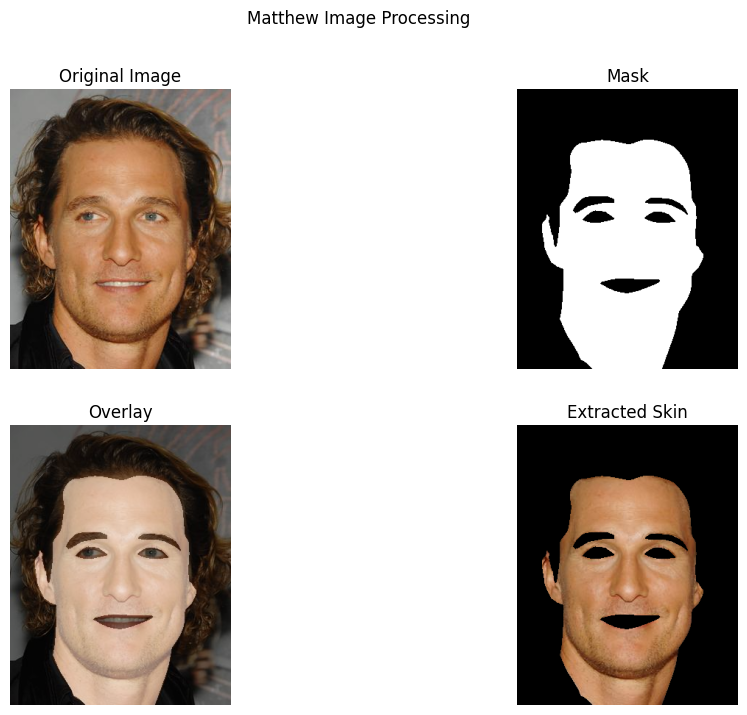

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from imageio import imread
import imageio.v2 as imageio

# -------------------------------
# File Paths (Colab / Local)
# -------------------------------

image_path = "/content/Matthew.jpg"
mask_path = "/content/Matthew_mask.png"

# -------------------------------
# Load Images
# -------------------------------

image = imread(image_path)
mask = imread(mask_path)

print("Image Shape:", image.shape)
print("Mask Shape:", mask.shape)

# -------------------------------
# Skin Extraction
# -------------------------------

def extract_skin(image, mask):
    mask_rgb = mask[:, :, :3]

    # White pixels = skin
    skin_pixels = np.all(mask_rgb == [255, 255, 255], axis=-1)

    skin_image = np.zeros_like(image)
    skin_image[skin_pixels] = image[skin_pixels]

    return skin_image, skin_pixels

# Apply extraction
skin_image, skin_pixels = extract_skin(image, mask)

# -------------------------------
# Skin Percentage Calculation
# -------------------------------

total_pixels = skin_pixels.size
skin_count = np.sum(skin_pixels)
skin_percentage = (skin_count / total_pixels) * 100

print("Skin Pixels:", skin_count)
print("Skin Percentage: %.2f%%" % skin_percentage)

# -------------------------------
# Display Results
# -------------------------------

plt.figure(figsize=(12,8))

plt.subplot(2,2,1)
plt.imshow(image)
plt.title("Original Image")
plt.axis("off")

plt.subplot(2,2,2)
plt.imshow(mask)
plt.title("Mask")
plt.axis("off")

plt.subplot(2,2,3)
plt.imshow(image)
plt.imshow(mask, alpha=0.4)
plt.title("Overlay")
plt.axis("off")

plt.subplot(2,2,4)
plt.imshow(skin_image)
plt.title("Extracted Skin")
plt.axis("off")

plt.suptitle("Matthew Image Processing")
plt.show()